# Problématique du projet

L'objectif du challenge est de modéliser les variations journalières du prix des contrats futures d'électricité pour la France et l'Allemagne à partir de variables explicatives météorologiques, énergétiques et commerciales.

Il s'agit d'un problème de régression supervisée dans lequel la variable cible correspond à la variation du prix de l'électricité à court terme (24h). L'objectif principal est d'expliquer les variations relatives du prix plutôt qu'en estimer la valeur. Cela est reflété par la métrique de corrélation de Spearman qui mesure la capacité du modèle à correctement ordonner les observations. Les données incluent notamment des variations journalières du prix des matières premières (Gaz, Charbon et futures sur les émissions carbone), des mesures météorologiques (température, pluie et vent), des mesures de productions (gaz naturel, charbon, hydrolique, nucléaire, photovoltaïque, éolienne, lignite) ainsi que des mesures d'utilisation électrique (consommation, exports, échanges entre la France et l'Allemagne).

Contexte du marché de l'électricité : 
Le marché de l'électricité est un marché où l'actif est physique et non stockable. Son prix est fixé par le coût marginal de la dernière unité de production (merit order). La France et l'Allemagne au dela que leur proximité et de leur frontière en commun, importent et exportent de l'électricité entre leur deux pays. En effet, ayant des mix énergétiques bien différents (plutôt nucléaire pour la France et renouvelable pour l'Allemagne), des arbitrages peuvent avoir lieu entre ces deux pays.

Lors d'évènement météorologique où le vent et le soleil sont absents, l'Allemagne doit allumer leurs centrales à charbon. Afin de palier à cette méthode de production d'électricité qui coûte cher, l'Allemagne peut acheter de l'électricité produite par les centrales française. Nous voyons donc tout l'intérêt d'étudier ces deux pays, lié dans la production d'électricité.

## Problématique

# Data processing

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn as sm

from pathlib import Path
import os

In [2]:
# data set entrainement
possible_paths = [
    Path("/Users/yves-mariesaliou/Documents/Cours/M2 IEF 272/MACHINE LEARNING/PROJET QRT ELEC"),
    Path("/Users/liessenathan/Desktop/M2/ML/PROJET-QRT-ELEC")
]
path = next((p for p in possible_paths if p.exists()), None)
path = str(path)

x_train = pd.read_csv(os.path.join(path, "X_train_NHkHMNU.csv")).sort_values(by=["COUNTRY", "DAY_ID"])
y_train = pd.read_csv(os.path.join(path, "y_train_ZAN5mwg.csv"))

# ensemble de test
x_test = pd.read_csv(os.path.join(path, "X_test_final.csv"))
y_test = pd.read_csv(os.path.join(path, "y_test_random_final.csv"))

## Visualisation

In [3]:
display(x_train.head(5))
display(y_train.head(5))

,ID,DAY_ID,COUNTRY,DE_CONSUMPTION,FR_CONSUMPTION,DE_FR_EXCHANGE,FR_DE_EXCHANGE,DE_NET_EXPORT,FR_NET_EXPORT,DE_NET_IMPORT,...,FR_RESIDUAL_LOAD,DE_RAIN,FR_RAIN,DE_WIND,FR_WIND,DE_TEMP,FR_TEMP,GAS_RET,COAL_RET,CARBON_RET
1468,111,2,DE,-0.068972,-0.667390,-1.102015,1.102015,-1.080403,0.256736,1.080403,...,-0.540642,-0.344600,-0.372156,-0.623041,-0.926064,-0.148950,0.641235,1.802550,1.140920,0.900434
680,800,3,DE,-0.134670,-0.834564,-1.051716,1.051716,-1.881881,-0.612133,1.881881,...,-0.856321,-1.394561,-1.118297,0.244859,0.488650,-1.710888,-0.951057,0.440121,-0.064550,-0.032756
991,831,5,DE,-0.297850,-0.470371,0.144615,-0.144615,-1.208286,-1.811403,1.208286,...,-0.552878,-1.374757,-0.790071,0.333817,0.021868,-0.062187,1.459745,-0.117977,0.550433,0.781870
1356,779,7,DE,0.057599,-0.625625,0.002239,-0.002239,-0.676226,-0.745182,0.676226,...,-0.806379,-0.531862,-0.663419,0.098940,1.367421,-0.812164,0.954384,-0.379980,0.518459,-0.034642
713,841,8,DE,-0.282744,-0.700027,1.309253,-1.309253,0.248085,-2.226840,-0.248085,...,-0.791016,1.522720,-0.307449,1.690497,1.584210,-0.441943,-0.382423,1.557325,0.146634,2.329924


,ID,TARGET
0,1054,0.028313
1,2049,-0.112516
2,1924,-0.180840
3,297,-0.260356
4,1101,-0.071733


## Types / Shape

In [4]:
display(x_train.dtypes)
display(x_train.shape)

ID                    int64
DAY_ID                int64
COUNTRY              object
DE_CONSUMPTION      float64
FR_CONSUMPTION      float64
DE_FR_EXCHANGE      float64
FR_DE_EXCHANGE      float64
DE_NET_EXPORT       float64
FR_NET_EXPORT       float64
DE_NET_IMPORT       float64
FR_NET_IMPORT       float64
DE_GAS              float64
FR_GAS              float64
DE_COAL             float64
FR_COAL             float64
DE_HYDRO            float64
FR_HYDRO            float64
DE_NUCLEAR          float64
FR_NUCLEAR          float64
DE_SOLAR            float64
FR_SOLAR            float64
DE_WINDPOW          float64
FR_WINDPOW          float64
DE_LIGNITE          float64
DE_RESIDUAL_LOAD    float64
FR_RESIDUAL_LOAD    float64
DE_RAIN             float64
FR_RAIN             float64
DE_WIND             float64
FR_WIND             float64
DE_TEMP             float64
FR_TEMP             float64
GAS_RET             float64
COAL_RET            float64
CARBON_RET          float64
dtype: object

(1494, 35)

## Statistiques descriptives

In [5]:
x_train[[col for col in x_train.columns if "ID" not in col]].describe()
# on a donc 30 variables explicatives disponibles pour notre Y

,DE_CONSUMPTION,FR_CONSUMPTION,DE_FR_EXCHANGE,FR_DE_EXCHANGE,DE_NET_EXPORT,FR_NET_EXPORT,DE_NET_IMPORT,FR_NET_IMPORT,DE_GAS,FR_GAS,...,DE_LIGNITE,DE_RAIN,FR_RAIN,DE_WIND,FR_WIND,DE_TEMP,FR_TEMP,GAS_RET,COAL_RET,CARBON_RET
count,1494.000000,1494.000000,1469.000000,1469.000000,1370.000000,1424.000000,1370.000000,1424.000000,1494.000000,1494.000000,...,1494.000000,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000,1494.000000,1494.000000,1494.000000
mean,0.427442,-0.020032,-0.145508,0.145508,-0.256332,-0.072643,0.256332,0.072643,0.780699,0.395019,...,-0.298856,-0.037831,0.019357,0.109480,0.123099,0.009451,0.008404,0.058126,0.061724,0.080510
std,0.673412,0.918995,0.970226,0.970226,0.957443,1.075830,0.957443,1.075830,0.850190,0.906500,...,0.851339,0.984233,1.051781,1.056243,1.054692,0.972394,1.003356,1.097768,1.033853,1.098624
min,-2.265563,-1.462350,-2.856874,-2.634831,-2.464849,-2.825331,-2.279619,-1.951516,-1.117260,-1.317350,...,-2.879041,-2.128531,-1.726420,-1.880419,-1.895319,-4.549638,-5.787097,-5.349463,-5.706442,-4.281790
25%,-0.037421,-0.716771,-0.875213,-0.638867,-0.977214,-0.851500,-0.452252,-0.794843,0.134947,-0.205078,...,-0.787239,-0.642117,-0.503927,-0.652135,-0.672614,-0.618259,-0.647948,-0.624238,-0.458038,-0.522968
50%,0.357061,-0.394166,-0.164287,0.164287,-0.306899,0.099455,0.306899,-0.099455,0.740006,0.256780,...,-0.188300,-0.274901,-0.228147,-0.261571,-0.229031,-0.026306,-0.020889,0.008493,0.063312,0.054056
75%,0.922057,0.650533,0.638867,0.875213,0.452252,0.794843,0.977214,0.851500,1.399461,1.090646,...,0.273510,0.335237,0.154351,0.635050,0.824781,0.651832,0.699131,0.676415,0.641446,0.599094
max,2.033851,3.300640,2.634831,2.856874,2.279619,1.951516,2.464849,2.825331,3.118082,2.372570,...,1.586885,7.756118,9.473201,5.085624,4.965028,2.858758,2.817239,5.674778,3.746576,5.471818


## Target

<Axes: title={'center': 'Return Prix Electricité DE'}, xlabel='DAY_ID'>

<Axes: title={'center': 'Return Prix Electricité FR'}, xlabel='DAY_ID'>

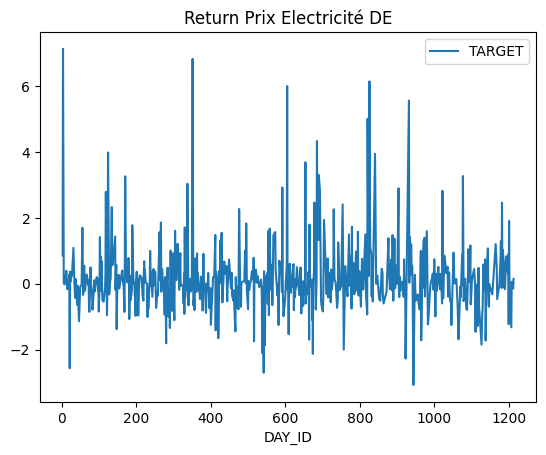

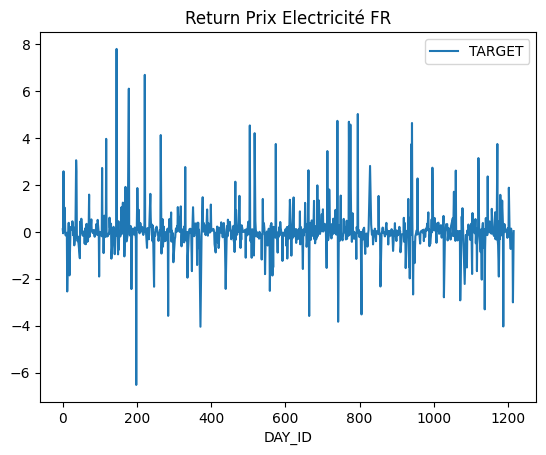

In [6]:
for country in x_train.COUNTRY.unique():
    display(x_train.query(f"COUNTRY == '{country}'")
            .merge(y_train).sort_values(by="DAY_ID")
            .plot(x="DAY_ID", y="TARGET", title=f"Return Prix Electricité {country}"))

## Gestion des valeurs manquantes

In [7]:
x_train.columns

Index(['ID', 'DAY_ID', 'COUNTRY', 'DE_CONSUMPTION', 'FR_CONSUMPTION',
       'DE_FR_EXCHANGE', 'FR_DE_EXCHANGE', 'DE_NET_EXPORT', 'FR_NET_EXPORT',
       'DE_NET_IMPORT', 'FR_NET_IMPORT', 'DE_GAS', 'FR_GAS', 'DE_COAL',
       'FR_COAL', 'DE_HYDRO', 'FR_HYDRO', 'DE_NUCLEAR', 'FR_NUCLEAR',
       'DE_SOLAR', 'FR_SOLAR', 'DE_WINDPOW', 'FR_WINDPOW', 'DE_LIGNITE',
       'DE_RESIDUAL_LOAD', 'FR_RESIDUAL_LOAD', 'DE_RAIN', 'FR_RAIN', 'DE_WIND',
       'FR_WIND', 'DE_TEMP', 'FR_TEMP', 'GAS_RET', 'COAL_RET', 'CARBON_RET'],
      dtype='object')

In [8]:
x_train.isna().sum()

ID                    0
DAY_ID                0
COUNTRY               0
DE_CONSUMPTION        0
FR_CONSUMPTION        0
DE_FR_EXCHANGE       25
FR_DE_EXCHANGE       25
DE_NET_EXPORT       124
FR_NET_EXPORT        70
DE_NET_IMPORT       124
FR_NET_IMPORT        70
DE_GAS                0
FR_GAS                0
DE_COAL               0
FR_COAL               0
DE_HYDRO              0
FR_HYDRO              0
DE_NUCLEAR            0
FR_NUCLEAR            0
DE_SOLAR              0
FR_SOLAR              0
DE_WINDPOW            0
FR_WINDPOW            0
DE_LIGNITE            0
DE_RESIDUAL_LOAD      0
FR_RESIDUAL_LOAD      0
DE_RAIN              94
FR_RAIN              94
DE_WIND              94
FR_WIND              94
DE_TEMP              94
FR_TEMP              94
GAS_RET               0
COAL_RET              0
CARBON_RET            0
dtype: int64

### RAIN/WIND/TEMP Completion

In [9]:
columns_to_fill = ["DE_RAIN", "FR_RAIN", "DE_WIND", "FR_WIND", "DE_TEMP", "FR_TEMP"]
x_train[["DAY_ID", "COUNTRY"] + columns_to_fill]

,DAY_ID,COUNTRY,DE_RAIN,FR_RAIN,DE_WIND,FR_WIND,DE_TEMP,FR_TEMP
1468,2,DE,-0.344600,-0.372156,-0.623041,-0.926064,-0.148950,0.641235
680,3,DE,-1.394561,-1.118297,0.244859,0.488650,-1.710888,-0.951057
991,5,DE,-1.374757,-0.790071,0.333817,0.021868,-0.062187,1.459745
1356,7,DE,-0.531862,-0.663419,0.098940,1.367421,-0.812164,0.954384
713,8,DE,1.522720,-0.307449,1.690497,1.584210,-0.441943,-0.382423
...,...,...,...,...,...,...,...,...
479,1208,FR,-1.224735,2.661142,0.472212,0.630211,1.065727,-1.439105
1451,1209,FR,0.457145,-0.202629,-0.395438,-0.463636,-0.251075,-0.387127
1007,1212,FR,-0.039379,-0.237434,1.358211,1.123953,-0.707839,-0.308232
873,1213,FR,NaN,NaN,NaN,NaN,NaN,NaN


### Interpolation linéaire

In [10]:
x_train_interpo = x_train.sort_values(["COUNTRY", "DAY_ID"]).copy()

for col in columns_to_fill:
    # interpolation separement pour chaque pays afin d'eviter de melanger DE et FR
    x_train_interpo[col] = x_train_interpo.groupby("COUNTRY")[col].transform(
        lambda s: s.interpolate(method="linear").ffill().bfill()
    )

In [11]:
display(x_train_interpo[["DAY_ID", "COUNTRY"] + columns_to_fill])
display(x_train_interpo.isna().sum().sort_values(ascending=False))

,DAY_ID,COUNTRY,DE_RAIN,FR_RAIN,DE_WIND,FR_WIND,DE_TEMP,FR_TEMP
1468,2,DE,-0.344600,-0.372156,-0.623041,-0.926064,-0.148950,0.641235
680,3,DE,-1.394561,-1.118297,0.244859,0.488650,-1.710888,-0.951057
991,5,DE,-1.374757,-0.790071,0.333817,0.021868,-0.062187,1.459745
1356,7,DE,-0.531862,-0.663419,0.098940,1.367421,-0.812164,0.954384
713,8,DE,1.522720,-0.307449,1.690497,1.584210,-0.441943,-0.382423
...,...,...,...,...,...,...,...,...
479,1208,FR,-1.224735,2.661142,0.472212,0.630211,1.065727,-1.439105
1451,1209,FR,0.457145,-0.202629,-0.395438,-0.463636,-0.251075,-0.387127
1007,1212,FR,-0.039379,-0.237434,1.358211,1.123953,-0.707839,-0.308232
873,1213,FR,-0.342771,0.250384,0.227416,0.120661,-0.477558,0.223629


DE_NET_EXPORT       124
DE_NET_IMPORT       124
FR_NET_IMPORT        70
FR_NET_EXPORT        70
DE_FR_EXCHANGE       25
FR_DE_EXCHANGE       25
DE_WIND               0
DE_LIGNITE            0
DE_RESIDUAL_LOAD      0
FR_RESIDUAL_LOAD      0
DE_RAIN               0
FR_RAIN               0
ID                    0
FR_WIND               0
DE_TEMP               0
DE_WINDPOW            0
FR_TEMP               0
GAS_RET               0
COAL_RET              0
FR_WINDPOW            0
DE_NUCLEAR            0
FR_SOLAR              0
DE_SOLAR              0
FR_NUCLEAR            0
DAY_ID                0
FR_HYDRO              0
DE_HYDRO              0
FR_COAL               0
DE_COAL               0
FR_GAS                0
DE_GAS                0
FR_CONSUMPTION        0
DE_CONSUMPTION        0
COUNTRY               0
CARBON_RET            0
dtype: int64

### Kalman filter

In [12]:
import numpy as np
import pandas as pd
from pykalman import KalmanFilter


def kalman_impute_1d(
    s: pd.Series,
    transition_covariance: float = 0.01,
    observation_covariance: float = 1.0,
    initial_state_covariance: float = 1.0,
) -> pd.Series:
    """
    Impute une série temporelle 1D avec un modèle d'état très simple :
        x_t = x_{t-1} + bruit_process
        y_t = x_t + bruit_obs

    Les NaN sont traités comme observations manquantes.
    """
    # conversion float
    values = s.astype(float).to_numpy()

    # masque des valeurs manquantes
    mask = np.isnan(values)

    # pykalman accepte des masked arrays pour les observations manquantes
    observations = np.ma.masked_array(values, mask=mask)

    # Modèle local level :
    # état latent scalaire, transition = 1, observation = 1
    kf = KalmanFilter(
        transition_matrices=[1.0],
        observation_matrices=[1.0],
        initial_state_mean=np.nanmean(values) if np.isfinite(values).any() else 0.0,
        initial_state_covariance=initial_state_covariance,
        transition_covariance=transition_covariance,
        observation_covariance=observation_covariance,
    )

    # lissage sur toute la série (meilleur que filter() pour interpolation offline)
    state_means, _ = kf.smooth(observations)

    # état latent reconstruit
    filled = pd.Series(state_means[:, 0], index=s.index)

    return filled


def kalman_impute_by_group(
    df: pd.DataFrame,
    group_col: str,
    time_col: str,
    columns_to_fill: list[str],
    transition_covariance: float = 0.01,
    observation_covariance: float = 1.0,
    initial_state_covariance: float = 1.0,
) -> pd.DataFrame:
    """
    Trie par groupe + temps, puis impute chaque colonne séparément dans chaque groupe.
    """
    df = df.sort_values([group_col, time_col]).copy()

    for col in columns_to_fill:
        df[col] = (
            df.groupby(group_col, group_keys=False)[col]
            .apply(
                lambda s: kalman_impute_1d(
                    s,
                    transition_covariance=transition_covariance,
                    observation_covariance=observation_covariance,
                    initial_state_covariance=initial_state_covariance,
                )
            )
        )

    return df

In [13]:
x_train_kalman = kalman_impute_by_group(
    df=x_train,
    group_col="COUNTRY",
    time_col="DAY_ID",
    columns_to_fill=columns_to_fill,
    transition_covariance=0.01,   # plus grand = série plus souple
    observation_covariance=1.0,   # plus grand = on "fait moins confiance" aux observations
)

### Median

In [14]:
x_train_median = x_train.copy()

for col in columns_to_fill:
    x_train_median[col] = x_train_median[col].fillna(
        x_train_median.groupby("COUNTRY")[col].transform("median")
    )

## Flux

Logiquement on a 
- DE_FR_EXCHANGE = - FR_DE_EXCHANGE
- DE_NET_EXPORT = - DE_NET_IMPORT
- FR_NET_EXPORT = - FR_NET_IMPORT

In [16]:
flow_pairs = [
    ("DE_FR_EXCHANGE", "FR_DE_EXCHANGE"),
    ("DE_NET_EXPORT", "DE_NET_IMPORT"),
    ("FR_NET_EXPORT", "FR_NET_IMPORT"),
    ]


x_train = x_train.sort_values("DAY_ID")

flux_cols = [c for pair in flow_pairs for c in pair]

In [17]:
display(x_train[["DAY_ID", "COUNTRY"] + flux_cols])
display(x_train.isna().sum().sort_values(ascending=False))

,DAY_ID,COUNTRY,DE_FR_EXCHANGE,FR_DE_EXCHANGE,DE_NET_EXPORT,DE_NET_IMPORT,FR_NET_EXPORT,FR_NET_IMPORT
742,0,FR,-0.079296,0.079296,NaN,NaN,0.650577,-0.650577
1211,1,FR,0.331356,-0.331356,0.405549,-0.405549,0.778627,-0.778627
1408,2,FR,-1.102015,1.102015,-1.080403,1.080403,0.256736,-0.256736
1468,2,DE,-1.102015,1.102015,-1.080403,1.080403,0.256736,-0.256736
680,3,DE,-1.051716,1.051716,-1.881881,1.881881,-0.612133,0.612133
...,...,...,...,...,...,...,...,...
986,1212,DE,-0.270515,0.270515,-0.137917,0.137917,-0.789824,0.789824
1007,1212,FR,-0.270515,0.270515,-0.137917,0.137917,-0.789824,0.789824
1465,1213,DE,-0.456126,0.456126,0.333142,-0.333142,-0.069222,0.069222
873,1213,FR,-0.456126,0.456126,0.333142,-0.333142,-0.069222,0.069222


DE_NET_EXPORT       124
DE_NET_IMPORT       124
DE_RAIN              94
FR_TEMP              94
DE_TEMP              94
FR_WIND              94
DE_WIND              94
FR_RAIN              94
FR_NET_IMPORT        70
FR_NET_EXPORT        70
DE_FR_EXCHANGE       25
FR_DE_EXCHANGE       25
DE_LIGNITE            0
DE_RESIDUAL_LOAD      0
FR_RESIDUAL_LOAD      0
ID                    0
DE_WINDPOW            0
GAS_RET               0
COAL_RET              0
FR_WINDPOW            0
DE_NUCLEAR            0
FR_SOLAR              0
DE_SOLAR              0
FR_NUCLEAR            0
DAY_ID                0
FR_HYDRO              0
DE_HYDRO              0
FR_COAL               0
DE_COAL               0
FR_GAS                0
DE_GAS                0
FR_CONSUMPTION        0
DE_CONSUMPTION        0
COUNTRY               0
CARBON_RET            0
dtype: int64

In [18]:
# interpolation linéaire
for a, b in flow_pairs:
    x_train_interpo[a] = x_train_interpo.groupby("COUNTRY")[a].transform(
        lambda s: s.interpolate(method="linear", limit_direction="both")
    )
    x_train_interpo[b] = x_train_interpo.groupby("COUNTRY")[b].transform(
        lambda s: s.interpolate(method="linear", limit_direction="both")
    )

# kalman
x_train_kalman = kalman_impute_by_group(
    df=x_train_kalman,
    group_col="COUNTRY",
    time_col="DAY_ID",
    columns_to_fill=flux_cols,
    transition_covariance=0.01,   # plus grand = série plus souple
    observation_covariance=1.0,   # plus grand = on "fait moins confiance" aux observations
)

# median
for col in flux_cols:
    x_train_median[col] = x_train_median[col].fillna(
        x_train_median.groupby("COUNTRY")[col].transform("median")
    )


In [ ]:
import itertools
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from sklearn.base import clone
from sklearn.linear_model import LinearRegression
lr = LinearRegression()


# --------------------------------------------------
# 1) Préparation
# --------------------------------------------------
# Important : trier avant les shifts temporels
x_base = x_train_median.sort_values(["COUNTRY", "DAY_ID"]).copy()

# cible alignée sur ID
y_train_clean = y_train.set_index("ID").loc[x_base["ID"], "TARGET"]


# --------------------------------------------------
# 2) Fonction de création des features avec shifts
# --------------------------------------------------
def build_features_with_shifts(df, temp_shift, rain_shift, wind_shift):
    df_feat = df.copy()

    # shifts par pays
    for country in df_feat["COUNTRY"].unique():
        mask = df_feat["COUNTRY"] == country

        df_feat.loc[mask, "FR_TEMP_LAG"] = df_feat.loc[mask, "FR_TEMP"].shift(temp_shift)
        df_feat.loc[mask, "DE_TEMP_LAG"] = df_feat.loc[mask, "DE_TEMP"].shift(temp_shift)

        df_feat.loc[mask, "FR_RAIN_LAG"] = df_feat.loc[mask, "FR_RAIN"].shift(rain_shift)
        df_feat.loc[mask, "DE_RAIN_LAG"] = df_feat.loc[mask, "DE_RAIN"].shift(rain_shift)

        df_feat.loc[mask, "FR_WIND_LAG"] = df_feat.loc[mask, "FR_WIND"].shift(wind_shift)
        df_feat.loc[mask, "DE_WIND_LAG"] = df_feat.loc[mask, "DE_WIND"].shift(wind_shift)

    # on enlève COUNTRY comme dans ton code
    df_feat = df_feat.drop(columns=["COUNTRY"])

    # fillna par médiane colonne par colonne
    medians = df_feat.median(numeric_only=True)
    df_feat = df_feat.fillna(medians)

    return df_feat


# --------------------------------------------------
# 3) Fonction de score
# --------------------------------------------------
def metric_train(y_true, y_pred):
    return spearmanr(y_pred, y_true).correlation


# --------------------------------------------------
# 4) Recherche exhaustive des combinaisons
# --------------------------------------------------
temp_shift_candidates = range(0, 8)
rain_shift_candidates = range(0, 8)
wind_shift_candidates = range(0, 8)

best_score = -np.inf
best_shifts = None
best_model = None
best_X = None

for temp_shift, rain_shift, wind_shift in itertools.product(
    temp_shift_candidates,
    rain_shift_candidates,
    wind_shift_candidates
):
    X_try = build_features_with_shifts(
        x_base,
        temp_shift=temp_shift,
        rain_shift=rain_shift,
        wind_shift=wind_shift
    )

    # clone du modèle pour éviter les effets de bord
    model = clone(lr)
    model.fit(X_try, y_train_clean)

    preds = model.predict(X_try)
    score = metric_train(y_train_clean, preds)

    if score > best_score:
        best_score = score
        best_shifts = {
            "TEMP_SHIFT": temp_shift,
            "RAIN_SHIFT": rain_shift,
            "WIND_SHIFT": wind_shift,
        }
        best_model = model
        best_X = X_try.copy()

        print(
            f"Nouveau meilleur score : {best_score:.6f} | "
            f"TEMP={temp_shift}, RAIN={rain_shift}, WIND={wind_shift}"
        )

print("\nMeilleure combinaison trouvée :", best_shifts)
print("Corrélation de Spearman train : {:.2f}%".format(100 * best_score))

Nouveau meilleur score : 0.281167 | TEMP=0, RAIN=0, WIND=0
Nouveau meilleur score : 0.281819 | TEMP=0, RAIN=0, WIND=1
Nouveau meilleur score : 0.284662 | TEMP=0, RAIN=0, WIND=3
Nouveau meilleur score : 0.286186 | TEMP=0, RAIN=1, WIND=3
Nouveau meilleur score : 0.286699 | TEMP=0, RAIN=2, WIND=1
Nouveau meilleur score : 0.289038 | TEMP=0, RAIN=2, WIND=3
Nouveau meilleur score : 0.290363 | TEMP=0, RAIN=6, WIND=3
Nouveau meilleur score : 0.291319 | TEMP=2, RAIN=6, WIND=3
Nouveau meilleur score : 0.291751 | TEMP=6, RAIN=6, WIND=3

Meilleure combinaison trouvée : {'TEMP_SHIFT': 6, 'RAIN_SHIFT': 6, 'WIND_SHIFT': 3}
Corrélation de Spearman train : 29.18%


# Construction des features

# Modèle simple - Benchmark

In [22]:
from scipy.stats import spearmanr
from sklearn.linear_model import LinearRegression

In [23]:
lr = LinearRegression()

x_train_clean = x_train.drop(['COUNTRY'], axis=1).fillna(0)
y_train_clean = y_train.set_index('ID').loc[x_train_clean['ID'], 'TARGET']

lr.fit(x_train_clean, y_train_clean)

output_train = lr.predict(x_train_clean)

def metric_train(output):
    return spearmanr(output, y_train_clean).correlation

print("Corrélation (Spearman) pour les données d'entrainement : {:.1f}%".format(100 * metric_train(output_train) ))

Corrélation (Spearman) pour les données d'entrainement : 27.9%


# Version avec median completion

In [24]:
lr = LinearRegression()

x_train_clean = x_train_median.drop(['COUNTRY'], axis=1).fillna(0)
y_train_clean = y_train.set_index('ID').loc[x_train_clean['ID'], 'TARGET']

lr.fit(x_train_clean, y_train_clean)

output_train = lr.predict(x_train_clean)

def metric_train(output):
    return spearmanr(output, y_train_clean).correlation

print("Corrélation (Spearman) pour les données d'entrainement : {:.1f}%".format(100 * metric_train(output_train) ))

Corrélation (Spearman) pour les données d'entrainement : 28.1%


### Version KNN

In [25]:
lr = LinearRegression()

x_train_clean = x_train_knn.drop(['COUNTRY'], axis=1).fillna(0)
y_train_clean = y_train.set_index('ID').loc[x_train_clean['ID'], 'TARGET']

lr.fit(x_train_clean, y_train_clean)

output_train = lr.predict(x_train_clean)

def metric_train(output):
    return spearmanr(output, y_train_clean).correlation

print("Corrélation (Spearman) pour les données d'entrainement : {:.1f}%".format(100 * metric_train(output_train) ))

Corrélation (Spearman) pour les données d'entrainement : 28.0%


# Version avec margin

In [26]:
lr = LinearRegression()

x_train_clean = x_train_median.drop(['COUNTRY'], axis=1).fillna(0)
y_train_clean = y_train.set_index('ID').loc[x_train_clean['ID'], 'TARGET']

lr.fit(x_train_clean, y_train_clean)

output_train = lr.predict(x_train_clean)

def metric_train(output):
    return spearmanr(output, y_train_clean).correlation

print("Corrélation (Spearman) pour les données d'entrainement : {:.1f}%".format(100 * metric_train(output_train) ))

Corrélation (Spearman) pour les données d'entrainement : 28.1%


# Version avec Lags

In [45]:
x_train_clean = x_train_median.drop(['COUNTRY'], axis=1).fillna(0)
y_train_clean = y_train.set_index('ID').loc[x_train_clean['ID'], 'TARGET']

### Ajout de lag dans les séries temporelles
x_train_clean[["FR_TEMP_LAG", "DE_TEMP_LAG"]] = x_train_clean[["FR_TEMP", "DE_TEMP"]].shift(best_shifts['TEMP_SHIFT']).fillna(0)
x_train_clean[["FR_RAIN_LAG", "DE_RAIN_LAG"]] = x_train_clean[["FR_RAIN", "DE_RAIN"]].shift(best_shifts['RAIN_SHIFT']).fillna(0)
x_train_clean[["FR_WIND_LAG", "DE_WIND_LAG"]] = x_train_clean[["FR_WIND", "DE_WIND"]].shift(best_shifts['WIND_SHIFT']).fillna(0)

lr.fit(x_train_clean, y_train_clean)

output_train = lr.predict(x_train_clean)

def metric_train(output):
    return spearmanr(output, y_train_clean).correlation

print("Corrélation (Spearman) pour les données d'entrainement : {:.1f}%".format(100 * metric_train(output_train) ))

Corrélation (Spearman) pour les données d'entrainement : 29.2%


## Ridge and Lasso regression

In [32]:
from sklearn.preprocessing import StandardScaler

df = x_train_clean.merge(y_train_clean, on='ID')
DROP_COLS = ["ID", "DAY_ID"]

X_raw = df.drop(columns=DROP_COLS + ['TARGET'])
X_raw = X_raw.fillna(X_raw.median())
y = df["TARGET"].values

# standardisation
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)
feature_names= X_raw.columns.tolist()

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'y — mean: {y.mean():.4f} | std: {y.std():.4f} | min: {y.min():.4f} | max: {y.max():.4f}')

X shape: (1494, 38)
y shape: (1494,)
y — mean: 0.0899 | std: 1.0342 | min: -6.5193 | max: 7.7866


### Ridge

In [46]:

from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import StandardScaler

alphas_grid = np.logspace(-3, 4, 200)
# validation croisee
kf = KFold(n_splits=5, shuffle=True, random_state=42)
ridge = RidgeCV(alphas=alphas_grid, cv=kf, scoring='neg_mean_squared_error')

ridge.fit(X, y)

print('=' * 50)
print('RIDGE')
print('=' * 50)

print(f'Alpha optimal  : {ridge.alpha_:.4f}')
print(f'R²  train      : {ridge.score(X, y):.4f}')

# R² en validation croisée : estimation non biaisée de la performance réelle
# On répète 5 fois : entraînement sur 4 folds, évaluation sur le 5ème
# La moyenne donne le score attendu sur de nouvelles données
cv_r2_ridge = cross_val_score(ridge, X, y, cv=kf, scoring='r2')

cv_rmse_ridge = np.sqrt(-cross_val_score(ridge, X, y, cv=kf, scoring='neg_mean_squared_error'))

# mean() = performance moyenne sur les 5 folds
# std()  = stabilité du modèle (std élevé = modèle instable selon le fold)
print(f'R²  CV (5-fold): {cv_r2_ridge.mean():.4f} ± {cv_r2_ridge.std():.4f}')
print(f'RMSE CV        : {cv_rmse_ridge.mean():.4f} ± {cv_rmse_ridge.std():.4f}')

# Coefficients Ridge :
# Contrairement à l'OLS, ils sont "shrinkés" (réduits) vers 0 mais jamais nuls
# Un coefficient élevé (en valeur absolue) = feature importante pour prédire Y
# On trie par valeur absolue décroissante pour voir les plus influentes en premier
coef_ridge = pd.Series(ridge.coef_, index=feature_names).sort_values(key=abs, ascending=False)
print(f'\nTop 10 coefficients Ridge :')
print(coef_ridge.head(10).to_string())


RIDGE
Alpha optimal  : 880.4884
R²  train      : 0.0469
R²  CV (5-fold): 0.0207 ± 0.0052
RMSE CV        : 1.0125 ± 0.1456

Top 10 coefficients Ridge :
DE_NET_EXPORT      -0.059234
DE_NET_IMPORT       0.059234
FR_WINDPOW         -0.042442
DE_WINDPOW         -0.027729
DE_HYDRO            0.025584
DE_FR_EXCHANGE      0.025331
FR_DE_EXCHANGE     -0.025331
DE_RESIDUAL_LOAD    0.024828
DE_TEMP_LAG         0.021950
DE_CONSUMPTION     -0.021844


### Lasso

In [47]:
# ============================================================
#  LASSO
# ============================================================

# LassoCV teste automatiquement plusieurs alphas par CV
# eps = ratio entre le plus petit et le plus grand alpha testé
# max_iter élevé car Lasso converge plus lentement que Ridge
lasso = LassoCV(
    alphas=np.logspace(-4, 1, 200),  # de 0.0001 à 10
    cv=kf,
    random_state=42,
    max_iter=50000
)
lasso.fit(X, y)

print('=' * 50)
print('LASSO')
print('=' * 50)
print(f'Alpha optimal  : {lasso.alpha_:.6f}')
print(f'R²  train      : {lasso.score(X, y):.4f}')

cv_r2_lasso   = cross_val_score(lasso, X, y, cv=kf, scoring='r2')
cv_rmse_lasso = np.sqrt(-cross_val_score(lasso, X, y, cv=kf, scoring='neg_mean_squared_error'))
print(f'R²  CV (5-fold): {cv_r2_lasso.mean():.4f} ± {cv_r2_lasso.std():.4f}')
print(f'RMSE CV        : {cv_rmse_lasso.mean():.4f} ± {cv_rmse_lasso.std():.4f}')

# Features sélectionnées = coefficients non nuls
coef_lasso = pd.Series(lasso.coef_, index=feature_names)
selected   = coef_lasso[coef_lasso != 0].sort_values(key=abs, ascending=False)
eliminated = coef_lasso[coef_lasso == 0].index.tolist()

print(f'\nFeatures retenues  : {len(selected)} / {len(feature_names)}')
print(f'Features éliminées : {eliminated}')
print(f'\nCoefficients non nuls :')
print(selected.to_string())

LASSO
Alpha optimal  : 0.024374
R²  train      : 0.0418
R²  CV (5-fold): 0.0209 ± 0.0074
RMSE CV        : 1.0124 ± 0.1456

Features retenues  : 10 / 38
Features éliminées : ['DE_CONSUMPTION', 'FR_CONSUMPTION', 'FR_DE_EXCHANGE', 'FR_NET_EXPORT', 'DE_NET_IMPORT', 'FR_NET_IMPORT', 'DE_GAS', 'FR_GAS', 'DE_COAL', 'FR_COAL', 'DE_NUCLEAR', 'FR_NUCLEAR', 'DE_SOLAR', 'DE_WINDPOW', 'DE_LIGNITE', 'DE_RAIN', 'FR_RAIN', 'DE_WIND', 'FR_WIND', 'DE_TEMP', 'FR_TEMP', 'COAL_RET', 'CARBON_RET', 'FR_TEMP_LAG', 'FR_RAIN_LAG', 'DE_RAIN_LAG', 'FR_WIND_LAG', 'DE_WIND_LAG']

Coefficients non nuls :
DE_NET_EXPORT      -0.160188
FR_RESIDUAL_LOAD    0.053555
FR_WINDPOW         -0.048132
DE_FR_EXCHANGE      0.047504
DE_RESIDUAL_LOAD    0.015926
DE_TEMP_LAG         0.010736
DE_HYDRO            0.010494
GAS_RET             0.005218
FR_SOLAR           -0.003183
FR_HYDRO            0.000196


Pour la regression Ridge (alpha=880): L'alpha optimal très élevé confirme la présence de forte colinéarité et de bruit dans les données. Ridge stabilise les coefficients mais ne fait pas de sélection - toutes les features restent dans le modèle avec des coefficients réduits.

Lasso (alpha=0,024) élimine automatiquement 27 features sur 30, ce qui suggère que la majorité des variables n'ont pas de relation linéaire significative avec TARGET.

# Modèle non supervisé (clustering)

In [36]:
# Variables retenues par le Lasso
features_lasso_selected = selected.index.tolist()

# Clustering uniquement sur les features sélectionnées
X_cluster = x_train_clean[features_lasso_selected].copy()
X_cluster = X_cluster.fillna(X_cluster.median())
X_cluster_scaled = StandardScaler().fit_transform(X_cluster)

print(f'Nombre de features Lasso : {len(features_lasso_selected)}')
print('Features utilisées pour le clustering :')
print(features_lasso_selected)
print(f'X_cluster shape : {X_cluster.shape}')

Nombre de features Lasso : 10
Features utilisées pour le clustering :
['DE_NET_EXPORT', 'FR_RESIDUAL_LOAD', 'FR_WINDPOW', 'DE_FR_EXCHANGE', 'DE_RESIDUAL_LOAD', 'DE_TEMP_LAG', 'DE_HYDRO', 'GAS_RET', 'FR_SOLAR', 'FR_HYDRO']
X_cluster shape : (1494, 10)


## K-means

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, mean_squared_error
from sklearn.model_selection import KFold, ParameterGrid
from sklearn.preprocessing import StandardScaler

In [38]:
x_train_clean = x_train_clean.fillna(x_train_clean.median())

In [39]:
features_lasso_selected = selected.index.tolist()
X_cluster = x_train_clean[features_lasso_selected].copy()
X_cluster = X_cluster.fillna(X_cluster.median())
X_cluster_scaled = StandardScaler().fit_transform(X_cluster)



## Choix du nombre de clusters - méthode du coude

,0
0,14940.000000
1,11455.256049
2,9852.234191
3,9007.148293
4,8521.993165


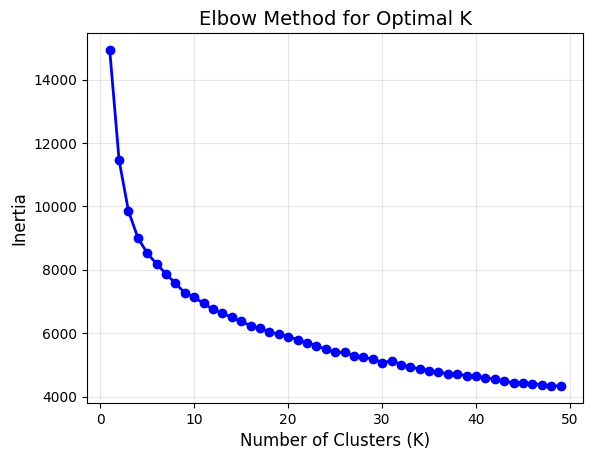

In [40]:
error=[]

for k in np.arange(1,50):
    kmean_temp = KMeans(n_clusters=k, random_state=0).fit(X_cluster_scaled)
    error.append(kmean_temp.inertia_)
errors = pd.DataFrame(error)
display(errors.head())

plt.plot(np.arange(1, 50), error, "bo-", linewidth=2)
plt.xlabel("Number of Clusters (K)", fontsize=12)
plt.ylabel("Inertia", fontsize=12)
plt.title("Elbow Method for Optimal K", fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()


## Choix du nombre de cluster - silhouette score

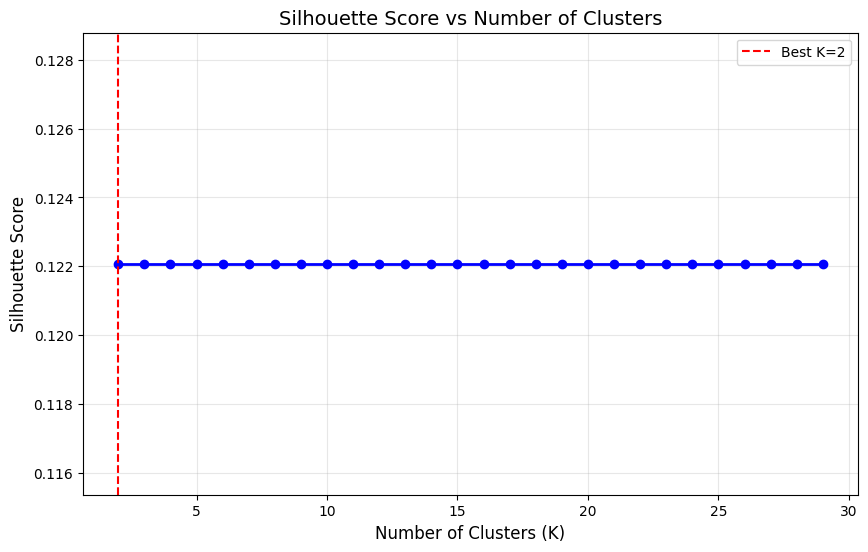

Optimal K: 2
Max Silhouette Score: 0.1221


In [41]:
silhouette_scores = []
K_range = np.arange(2,30)

for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=0).fit(X_cluster_scaled)
    score = silhouette_score(X_cluster_scaled, kmean_temp.labels_)
    silhouette_scores.append(score)


plt.figure(figsize=(10, 6))
plt.plot(K_range, silhouette_scores, 'bo-', linewidth=2)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette Score vs Number of Clusters', fontsize=14)
plt.grid(True, alpha=0.3)

best_k = K_range[np.argmax(silhouette_scores)]
plt.axvline(x=best_k, color='r', linestyle='--', label=f'Best K={best_k}')
plt.legend()
plt.show()

print(f"Optimal K: {best_k}")
print(f"Max Silhouette Score: {max(silhouette_scores):.4f}")

### Méhode du coude avec K opt = 4

In [42]:
kmeans_optim = KMeans(n_clusters=4, random_state=0).fit(X_cluster_scaled)
clusters = pd.DataFrame(kmeans_optim.cluster_centers_)

clust_data = clusters.T
nb_clusters = clusters.shape[0]
New_labels = ["Cluster " + str(x) for x in range(nb_clusters)]
clust_data.columns = New_labels
clust_data.head()

,Cluster 0,Cluster 1,Cluster 2,Cluster 3
0,0.112902,-0.935507,1.226734,0.329577
1,-0.490864,-0.654911,0.170821,1.336244
2,-0.432756,-0.335518,1.484447,-0.093902
3,0.480313,-0.953998,0.506349,0.456859
4,-0.337629,0.166553,-1.136767,0.931518


## Modèle prédictif : KMeans + Ridge par cluster

In [48]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GroupKFold, ParameterGrid

# Base de regression : on retire les identifiants et on impute les derniers NaN.
X_regression = x_train_clean.drop(columns=["ID", "DAY_ID"]).copy()
X_regression = X_regression.fillna(X_regression.median())
y_cluster_target = y_train_clean.to_numpy()

# Les folds sont construits par jour pour éviter les fuites d'information temporelles.
groups_cluster = x_train_clean["DAY_ID"].to_numpy()

# Le clustering est appris uniquement sur les variables sélectionnées par le Lasso.
cluster_features = selected.index.tolist()


# La metrique du projet est la correlation de Spearman.
def spearman_corr_safe(y_true, y_pred):
    corr = spearmanr(y_true, y_pred).correlation
    return 0.0 if np.isnan(corr) else corr


# Benchmark : une seule Ridge globale sur l'ensemble des observations.
def evaluate_global_ridge(alpha, X_data, y_data, groups):
    cv = GroupKFold(n_splits=5)
    oof_pred = np.zeros(len(X_data))
    train_scores = []

    for train_idx, valid_idx in cv.split(X_data, y_data, groups):
        X_train = X_data.iloc[train_idx]
        X_valid = X_data.iloc[valid_idx]
        y_train = y_data[train_idx]
        y_valid = y_data[valid_idx]

        # Standardisation apprise sur le fold train uniquement.
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_valid_scaled = scaler.transform(X_valid)

        model = Ridge(alpha=alpha)
        model.fit(X_train_scaled, y_train)

        train_pred = model.predict(X_train_scaled)
        valid_pred = model.predict(X_valid_scaled)

        train_scores.append(spearman_corr_safe(y_train, train_pred))
        oof_pred[valid_idx] = valid_pred

    return {
        "alpha": alpha,
        "train_spearman_mean": float(np.mean(train_scores)),
        "cv_spearman": float(spearman_corr_safe(y_data, oof_pred)),
    }


# Modele hybride : KMeans pour segmenter les observations puis une Ridge par cluster.
def evaluate_cluster_ridge(params, X_data, y_data, groups, cluster_cols):
    cv = GroupKFold(n_splits=5)
    oof_pred = np.zeros(len(X_data))
    train_scores = []
    fold_cluster_sizes = []

    for train_idx, valid_idx in cv.split(X_data, y_data, groups):
        X_train = X_data.iloc[train_idx].copy()
        X_valid = X_data.iloc[valid_idx].copy()
        y_train = y_data[train_idx]
        y_valid = y_data[valid_idx]

        # Le clustering est fait dans un espace standardisé restreint aux features Lasso.
        cluster_scaler = StandardScaler()
        X_train_cluster = cluster_scaler.fit_transform(X_train[cluster_cols])
        X_valid_cluster = cluster_scaler.transform(X_valid[cluster_cols])

        kmeans = KMeans(
            n_clusters=params["n_clusters"],
            n_init=params["n_init"],
            max_iter=params["max_iter"],
            random_state=42,
        )
        train_labels = kmeans.fit_predict(X_train_cluster)
        valid_labels = kmeans.predict(X_valid_cluster)

        # La regression utilise ensuite toutes les features de regression disponibles.
        reg_scaler = StandardScaler()
        X_train_scaled = reg_scaler.fit_transform(X_train)
        X_valid_scaled = reg_scaler.transform(X_valid)

        # Modele de secours : s'il manque des points dans un cluster, on garde une Ridge globale.
        global_model = Ridge(alpha=params["ridge_alpha"])
        global_model.fit(X_train_scaled, y_train)

        train_pred = global_model.predict(X_train_scaled)
        valid_pred = global_model.predict(X_valid_scaled)
        fold_cluster_sizes.append(pd.Series(train_labels).value_counts().sort_index().to_dict())

        # On remplace la prediction globale par une prediction locale des que le cluster est assez grand.
        for cluster_id in range(params["n_clusters"]):
            train_mask = train_labels == cluster_id
            valid_mask = valid_labels == cluster_id

            if train_mask.sum() < params["min_cluster_size"]:
                continue

            local_model = Ridge(alpha=params["ridge_alpha"])
            local_model.fit(X_train_scaled[train_mask], y_train[train_mask])

            train_pred[train_mask] = local_model.predict(X_train_scaled[train_mask])
            if valid_mask.any():
                valid_pred[valid_mask] = local_model.predict(X_valid_scaled[valid_mask])

        train_scores.append(spearman_corr_safe(y_train, train_pred))
        oof_pred[valid_idx] = valid_pred

    return {
        **params,
        "train_spearman_mean": float(np.mean(train_scores)),
        "cv_spearman": float(spearman_corr_safe(y_data, oof_pred)),
        "overfit_gap": float(np.mean(train_scores) - spearman_corr_safe(y_data, oof_pred)),
        "cluster_sizes_by_fold": fold_cluster_sizes,
    }


# Evaluation du benchmark de reference.
baseline_result = evaluate_global_ridge(
    alpha=1.0,
    X_data=X_regression,
    y_data=y_cluster_target,
    groups=groups_cluster,
)

# Petite grille d'hyperparametres pour optimiser le clustering predictive.
param_grid = {
    "n_clusters": [2, 3, 4, 5, 6],
    "ridge_alpha": [0.1, 1.0, 10.0, 100.0],
    "n_init": [10, 25],
    "max_iter": [300],
    "min_cluster_size": [30],
}

# Grid search manuel avec validation croisee groupee par DAY_ID.
grid_results = []
for params in ParameterGrid(param_grid):
    result = evaluate_cluster_ridge(
        params=params,
        X_data=X_regression,
        y_data=y_cluster_target,
        groups=groups_cluster,
        cluster_cols=cluster_features,
    )
    grid_results.append(result)

results_df = pd.DataFrame(grid_results).sort_values(
    by=["cv_spearman", "overfit_gap"],
    ascending=[False, True],
).reset_index(drop=True)

# On retient le modele qui maximise le score CV tout en limitant le sur-apprentissage.
best_cluster_model = results_df.iloc[0].to_dict()

comparison_df = pd.DataFrame([
    {
        "modele": "Ridge globale (benchmark)",
        "train_spearman_mean": baseline_result["train_spearman_mean"],
        "cv_spearman": baseline_result["cv_spearman"],
        "overfit_gap": baseline_result["train_spearman_mean"] - baseline_result["cv_spearman"],
    },
    {
        "modele": "KMeans + Ridge par cluster",
        "train_spearman_mean": best_cluster_model["train_spearman_mean"],
        "cv_spearman": best_cluster_model["cv_spearman"],
        "overfit_gap": best_cluster_model["overfit_gap"],
    },
])

# Les 10 meilleures configurations testees.
display(results_df[["n_clusters", "ridge_alpha", "n_init", "train_spearman_mean", "cv_spearman", "overfit_gap"]].head(10))
display(comparison_df)

print("Meilleurs hyperparamètres clustering :")
print({k: best_cluster_model[k] for k in ["n_clusters", "ridge_alpha", "n_init", "max_iter", "min_cluster_size"]})
print(f"Score CV Spearman du meilleur modèle : {100 * best_cluster_model['cv_spearman']:.2f}%")
print(f"Score train moyen : {100 * best_cluster_model['train_spearman_mean']:.2f}%")
print(f"Gap train - CV : {100 * best_cluster_model['overfit_gap']:.2f}%")
print("Tailles de clusters observées par fold (meilleur modèle) :")
for fold_id, sizes in enumerate(best_cluster_model["cluster_sizes_by_fold"], start=1):
    print(f"Fold {fold_id}: {sizes}")


,n_clusters,ridge_alpha,n_init,train_spearman_mean,cv_spearman,overfit_gap
0,2,100.0,10,0.310879,0.226363,0.084516
1,2,100.0,25,0.310598,0.225802,0.084796
2,2,10.0,10,0.320355,0.214798,0.105557
3,2,10.0,25,0.320132,0.214638,0.105494
4,2,1.0,10,0.322118,0.206818,0.115301
5,2,1.0,25,0.321898,0.206348,0.115550
6,2,0.1,10,0.321209,0.200220,0.120989
7,2,0.1,25,0.320970,0.200025,0.120946
8,5,100.0,10,0.337533,0.184228,0.153305
9,5,100.0,25,0.331714,0.181651,0.150063


,modele,train_spearman_mean,cv_spearman,overfit_gap
0,Ridge globale (benchmark),0.292691,0.221950,0.070740
1,KMeans + Ridge par cluster,0.310879,0.226363,0.084516


Meilleurs hyperparamètres clustering :
{'n_clusters': 2, 'ridge_alpha': 100.0, 'n_init': 10, 'max_iter': 300, 'min_cluster_size': 30}
Score CV Spearman du meilleur modèle : 22.64%
Score train moyen : 31.09%
Gap train - CV : 8.45%
Tailles de clusters observées par fold (meilleur modèle) :
Fold 1: {0: 705, 1: 490}
Fold 2: {0: 520, 1: 675}
Fold 3: {0: 520, 1: 675}
Fold 4: {0: 682, 1: 513}
Fold 5: {0: 480, 1: 716}


# Modèle supervisé (SVM, méthode ensembliste)

# Interprétation

# Modèle de deep learning (optionnel)